In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import re
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage import feature

## Importing labels and images into variables

In [20]:
home = "images"
directories = "train", "test", "val"
class_names = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

In [3]:
def read_file_to_list(file_path):
    numbers_list = []
    with open(file_path, 'r') as file:
        for line in file:
            number = int(line.strip())
            numbers_list.append(number)
        return numbers_list

In [4]:
y_train = read_file_to_list(f'{home}/{directories[0]}.txt')
y_test = read_file_to_list(f'{home}/{directories[1]}.txt')
y_val = read_file_to_list(f'{home}/{directories[2]}.txt')

In [5]:
train_folder = os.path.join(home, directories[0])
test_folder = os.path.join(home, directories[1])
val_folder = os.path.join(home, directories[2])

def get_image_content(folder_path):
    image_contents = []

    def extract_number(filename):
        match = re.search(r'\d+', filename)
        return int(match.group()) if match else -1

    filenames = sorted(os.listdir(folder_path), key=extract_number)

    for filename in filenames:
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path) and filename.endswith('.png'):
            image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            image_contents.append(image)

    return image_contents

x_train = get_image_content(train_folder)
x_test = get_image_content(test_folder)
x_val = get_image_content(val_folder)

In [9]:
def plot_loss_curves(history):
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']
  epochs = range(len(history.history['loss']))
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

In [34]:
def to_lbp(photos: list, num_points: int = 8, radius: int = 1):
    result = []
    for photo in photos:
        result.append(feature.local_binary_pattern(photo, num_points, radius, method='uniform'))
    return result

def to_clahe(photos: list, clip=5):
    result = []
    clahe = cv2.createCLAHE(clipLimit=clip)
    for photo in photos:
        final_img = clahe.apply(photo) + 30
        result.append(final_img)
    return result

## Training the CNN

In [6]:
x_train = np.array(x_train).reshape((-1, 224, 224, 1)).astype('float32')
x_val = np.array(x_val).reshape((-1, 224, 224, 1)).astype('float32')
x_test = np.array(x_test).reshape((-1, 224, 224, 1)).astype('float32')

y_train = tf.keras.utils.to_categorical(np.array(y_train), num_classes=4)
y_val = tf.keras.utils.to_categorical(np.array(y_val), num_classes=4)
y_test = tf.keras.utils.to_categorical(np.array(y_test), num_classes=4)

Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4296 - loss: 42.9808 - val_accuracy: 0.6943 - val_loss: 0.7913
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6718 - loss: 0.7844 - val_accuracy: 0.7393 - val_loss: 0.6411
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7318 - loss: 0.6714 - val_accuracy: 0.7654 - val_loss: 0.6261
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7662 - loss: 0.6152 - val_accuracy: 0.7915 - val_loss: 0.5739
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7799 - loss: 0.5782 - val_accuracy: 0.8033 - val_loss: 0.5798
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7875 - loss: 0.5585 - val_accuracy: 0.7938 - val_loss: 0.5632
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8001 - loss: 0.5270 - val_accuracy: 0.8009 - val_loss: 0.5514
Epoch 8/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8069 - loss: 0.5032 -

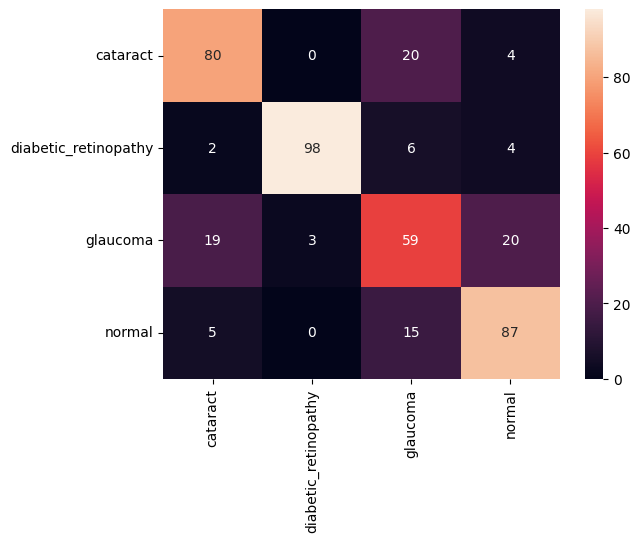

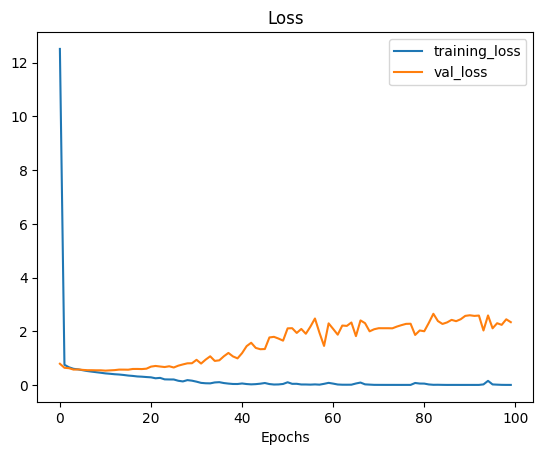

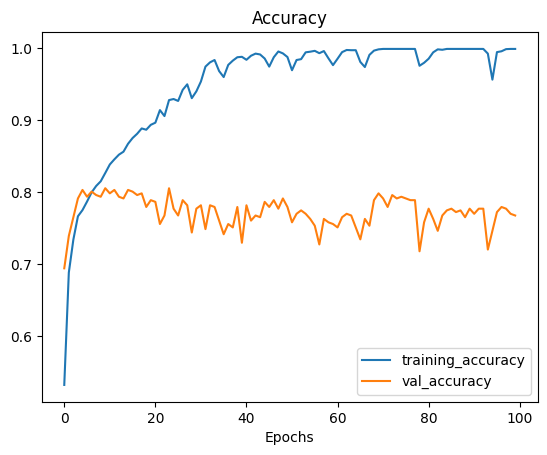

In [22]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
input_shape = (224, 224, 1)
model.add(tf.keras.layers.Conv2D(10, 3, activation="relu"))
model.add(tf.keras.layers.MaxPool2D())
model.add(tf.keras.layers.Conv2D(10, 3, activation="relu"))
model.add(tf.keras.layers.MaxPool2D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(4, activation="softmax"))

model.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

history = model.fit(x=x_train, y=y_train, epochs=100, validation_data=(x_val, y_val), batch_size=16)

y_pred_probs = model.predict(x_val)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)
test_loss, test_acc = model.evaluate(x_test, y_test)

conf_matrix = confusion_matrix(y_true, y_pred)

sns.heatmap(conf_matrix, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.show()

plot_loss_curves(history)

In [32]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [29]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 4

In [30]:
x_train_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(x_train))
x_val_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(x_val))
x_test_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(x_test))

x_train_rgb = x_train_rgb / 255.0
x_val_rgb = x_val_rgb / 255.0
x_test_rgb = x_test_rgb / 255.0

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 228ms/step - accuracy: 0.6399 - loss: 1.1564 - val_accuracy: 0.8246 - val_loss: 0.4766
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 234ms/step - accuracy: 0.8384 - loss: 0.4385 - val_accuracy: 0.8365 - val_loss: 0.4423
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 23s 217ms/step - accuracy: 0.8554 - loss: 0.3683 - val_accuracy: 0.8199 - val_loss: 0.4902
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 23s 221ms/step - accuracy: 0.8705 - loss: 0.3349 - val_accuracy: 0.8341 - val_loss: 0.4543
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 23s 217ms/step - accuracy: 0.8740 - loss: 0.3160 - val_accuracy: 0.8555 - val_loss: 0.4133
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 23s 217ms/step - accuracy: 0.9064 - loss: 0.2611 - val_accuracy: 0.8555 - val_loss: 0.4093
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 211ms/step - accuracy: 0.9085 - loss: 0.2281 - val_accuracy: 0.8507 - val_loss: 0.4518
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 239ms/step - accuracy: 0.9133 - loss: 0

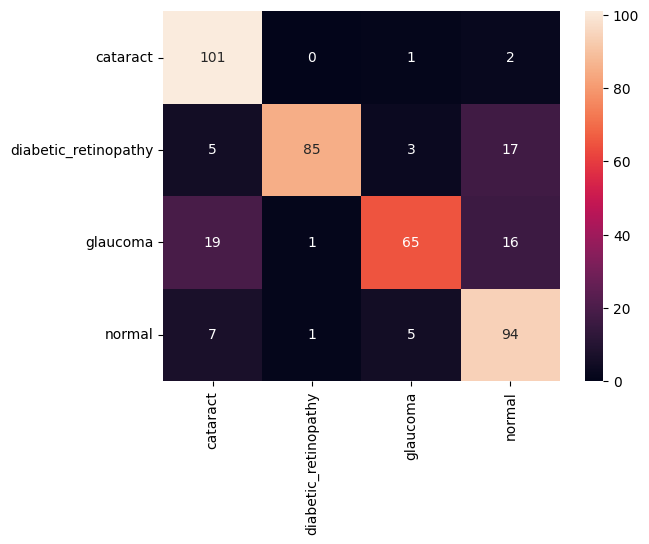

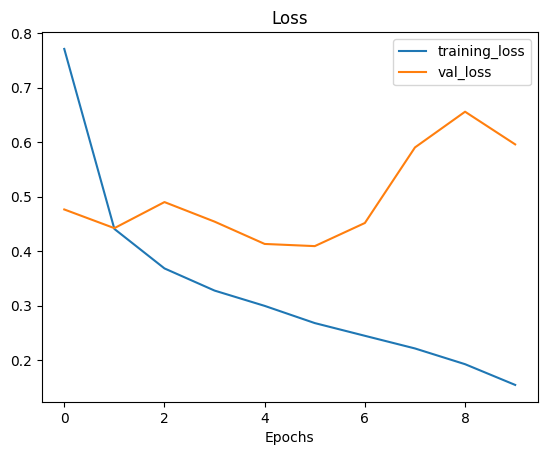

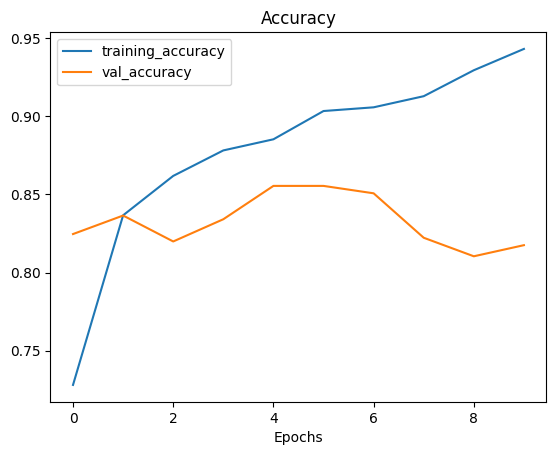

In [33]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs=predictions)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train_rgb, y_train, validation_data=(x_val_rgb, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE)

loss, accuracy = model.evaluate(x_test_rgb, y_test)

y_pred_probs = model.predict(x_val_rgb)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.show()

plot_loss_curves(history)

# LBP

Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3276 - loss: 10.5850 - val_accuracy: 0.6114 - val_loss: 0.8891
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6653 - loss: 0.8320 - val_accuracy: 0.6564 - val_loss: 0.8334
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7710 - loss: 0.6223 - val_accuracy: 0.6801 - val_loss: 0.8702
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8512 - loss: 0.4320 - val_accuracy: 0.6848 - val_loss: 0.8844
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9106 - loss: 0.2969 - val_accuracy: 0.6706 - val_loss: 0.9539
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9384 - loss: 0.2183 - val_accuracy: 0.6398 - val_loss: 1.0401
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9409 - loss: 0.1730 - val_accuracy: 0.6280 - val_loss: 1.2257
Epoch 8/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9610 - loss: 0.1417 -

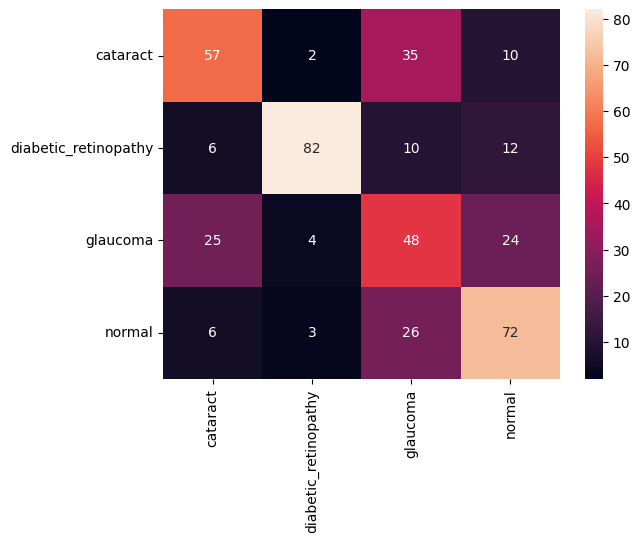

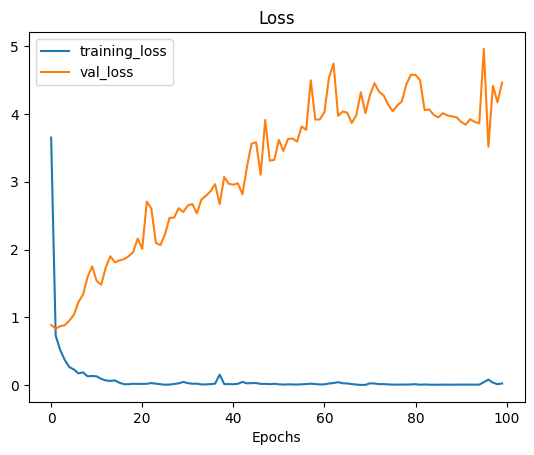

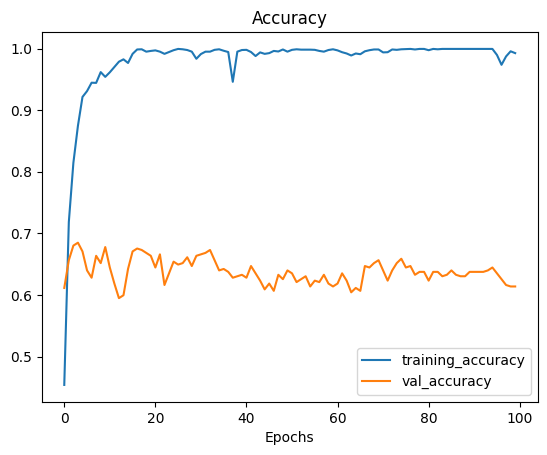

In [40]:
x_train = get_image_content(train_folder)
x_test = get_image_content(test_folder)
x_val = get_image_content(val_folder)

x_train = to_lbp(x_train)
x_test = to_lbp(x_test)
x_val = to_lbp(x_val)

x_train = np.array(x_train).reshape((-1, 224, 224, 1)).astype('float32')
x_val = np.array(x_val).reshape((-1, 224, 224, 1)).astype('float32')
x_test = np.array(x_test).reshape((-1, 224, 224, 1)).astype('float32')

tf.random.set_seed(42)
model = tf.keras.Sequential()
input_shape = (224, 224, 1)
model.add(tf.keras.layers.Conv2D(10, 3, activation="relu"))
model.add(tf.keras.layers.MaxPool2D())
model.add(tf.keras.layers.Conv2D(10, 3, activation="relu"))
model.add(tf.keras.layers.MaxPool2D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(4, activation="softmax"))

model.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

history = model.fit(x=x_train, y=y_train, epochs=100, validation_data=(x_val, y_val), batch_size=16)

y_pred_probs = model.predict(x_val)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)
test_loss, test_acc = model.evaluate(x_test, y_test)

conf_matrix = confusion_matrix(y_true, y_pred)

sns.heatmap(conf_matrix, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.show()

plot_loss_curves(history)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 43s 332ms/step - accuracy: 0.6535 - loss: 0.9994 - val_accuracy: 0.8199 - val_loss: 0.4912
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 32s 298ms/step - accuracy: 0.8260 - loss: 0.4388 - val_accuracy: 0.8294 - val_loss: 0.4474
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - accuracy: 0.8571 - loss: 0.3672 - val_accuracy: 0.8199 - val_loss: 0.5083
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 32s 303ms/step - accuracy: 0.8758 - loss: 0.3389 - val_accuracy: 0.8199 - val_loss: 0.4815
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 29s 268ms/step - accuracy: 0.8883 - loss: 0.2966 - val_accuracy: 0.8555 - val_loss: 0.4065
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 27s 255ms/step - accuracy: 0.9079 - loss: 0.2592 - val_accuracy: 0.8626 - val_loss: 0.3727
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 245ms/step - accuracy: 0.9080 - loss: 0.2336 - val_accuracy: 0.8602 - val_loss: 0.3951
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 235ms/step - accuracy: 0.9175 - loss: 0

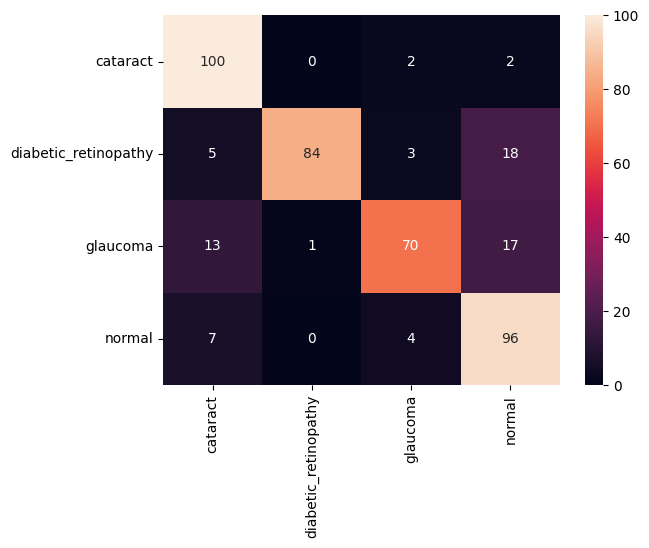

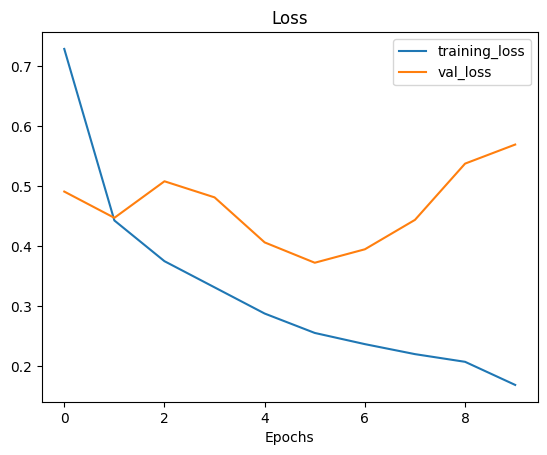

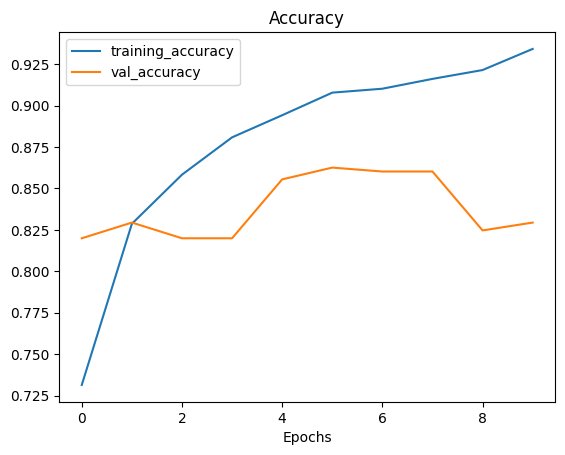

In [41]:
x_train = get_image_content(train_folder)
x_test = get_image_content(test_folder)
x_val = get_image_content(val_folder)

x_train = to_lbp(x_train)
x_test = to_lbp(x_test)
x_val = to_lbp(x_val)

x_train = np.array(x_train).reshape((-1, 224, 224, 1)).astype('float32')
x_val = np.array(x_val).reshape((-1, 224, 224, 1)).astype('float32')
x_test = np.array(x_test).reshape((-1, 224, 224, 1)).astype('float32')

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs=predictions)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train_rgb, y_train, validation_data=(x_val_rgb, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE)

loss, accuracy = model.evaluate(x_test_rgb, y_test)

y_pred_probs = model.predict(x_val_rgb)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.show()

plot_loss_curves(history)

# Clahe

Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4072 - loss: 58.4349 - val_accuracy: 0.5782 - val_loss: 1.0673
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6988 - loss: 0.7464 - val_accuracy: 0.6611 - val_loss: 1.0150
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8615 - loss: 0.3652 - val_accuracy: 0.7322 - val_loss: 0.9832
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9391 - loss: 0.1944 - val_accuracy: 0.7251 - val_loss: 1.2504
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9591 - loss: 0.1150 - val_accuracy: 0.7062 - val_loss: 1.3027
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9755 - loss: 0.0769 - val_accuracy: 0.7180 - val_loss: 1.4469
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9794 - loss: 0.0670 - val_accuracy: 0.6848 - val_loss: 1.6920
Epoch 8/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9662 - loss: 0.0978 -

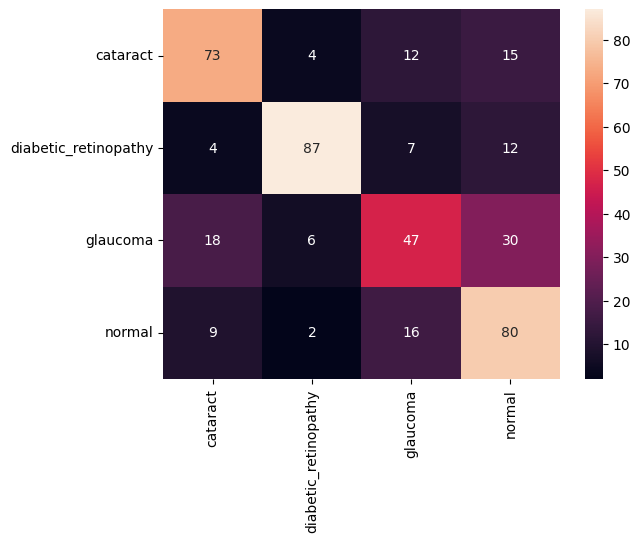

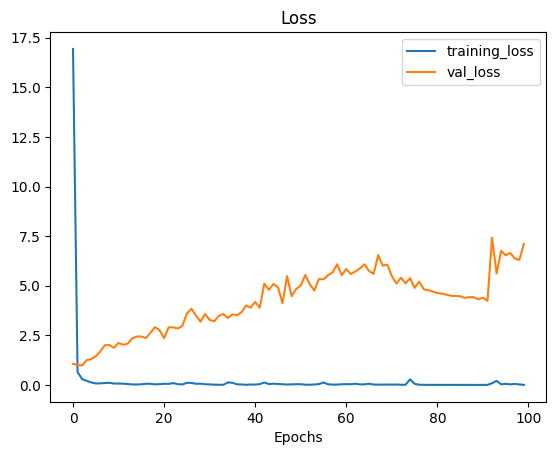

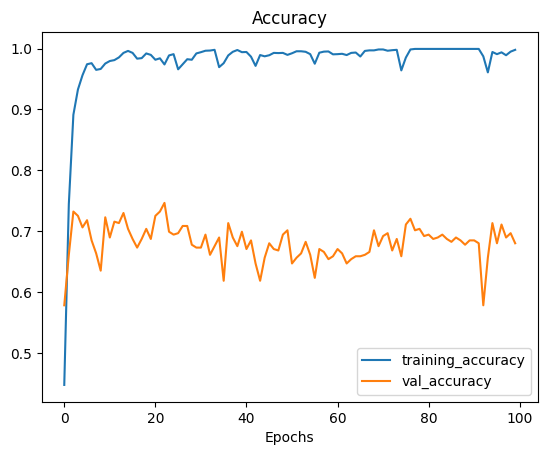

In [42]:
x_train = get_image_content(train_folder)
x_test = get_image_content(test_folder)
x_val = get_image_content(val_folder)

x_train = to_clahe(x_train)
x_test = to_clahe(x_test)
x_val = to_clahe(x_val)

x_train = np.array(x_train).reshape((-1, 224, 224, 1)).astype('float32')
x_val = np.array(x_val).reshape((-1, 224, 224, 1)).astype('float32')
x_test = np.array(x_test).reshape((-1, 224, 224, 1)).astype('float32')

tf.random.set_seed(42)
model = tf.keras.Sequential()
input_shape = (224, 224, 1)
model.add(tf.keras.layers.Conv2D(10, 3, activation="relu"))
model.add(tf.keras.layers.MaxPool2D())
model.add(tf.keras.layers.Conv2D(10, 3, activation="relu"))
model.add(tf.keras.layers.MaxPool2D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(4, activation="softmax"))

model.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

history = model.fit(x=x_train, y=y_train, epochs=100, validation_data=(x_val, y_val), batch_size=16)

y_pred_probs = model.predict(x_val)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)
test_loss, test_acc = model.evaluate(x_test, y_test)

conf_matrix = confusion_matrix(y_true, y_pred)

sns.heatmap(conf_matrix, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.show()

plot_loss_curves(history)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 31s 264ms/step - accuracy: 0.6134 - loss: 1.1068 - val_accuracy: 0.8365 - val_loss: 0.4874
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 27s 256ms/step - accuracy: 0.8283 - loss: 0.4508 - val_accuracy: 0.8223 - val_loss: 0.4642
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 27s 252ms/step - accuracy: 0.8538 - loss: 0.3730 - val_accuracy: 0.8460 - val_loss: 0.4458
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 247ms/step - accuracy: 0.8770 - loss: 0.3328 - val_accuracy: 0.8626 - val_loss: 0.3957
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 236ms/step - accuracy: 0.8864 - loss: 0.2933 - val_accuracy: 0.8578 - val_loss: 0.3674
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 27s 256ms/step - accuracy: 0.9100 - loss: 0.2455 - val_accuracy: 0.8673 - val_loss: 0.3898
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 247ms/step - accuracy: 0.9236 - loss: 0.2152 - val_accuracy: 0.8626 - val_loss: 0.4128
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 245ms/step - accuracy: 0.9350 - loss: 0

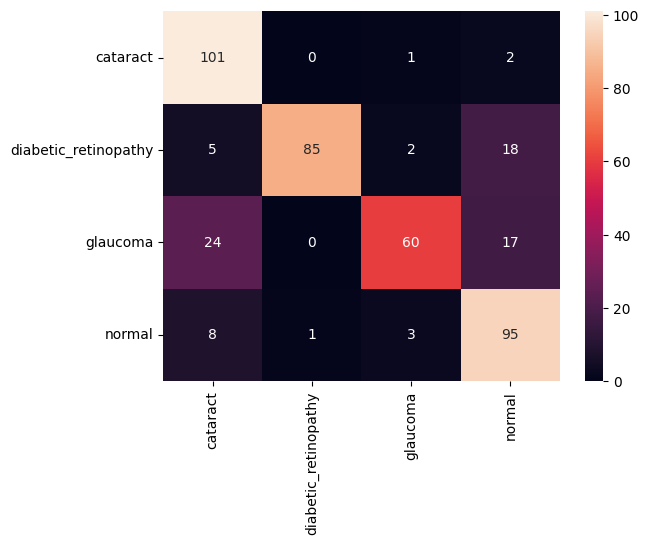

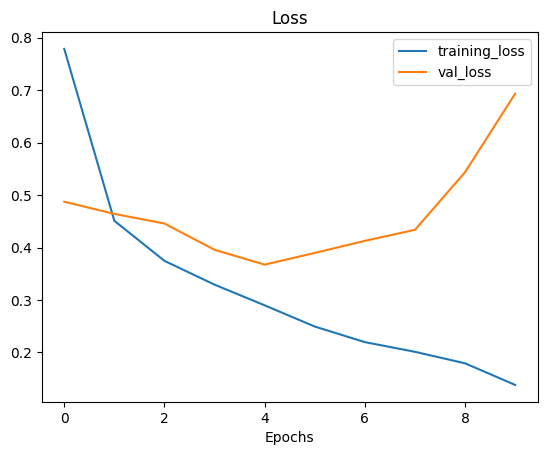

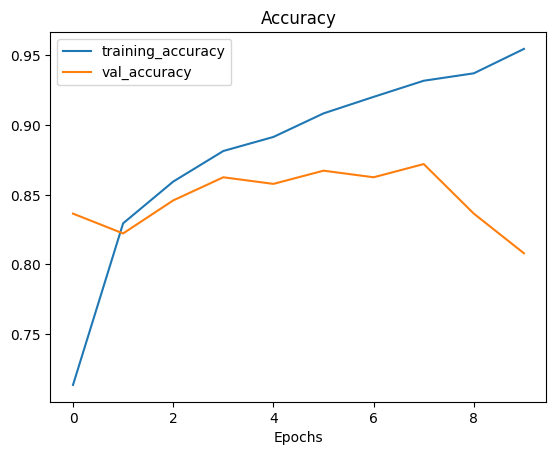

In [43]:
x_train = get_image_content(train_folder)
x_test = get_image_content(test_folder)
x_val = get_image_content(val_folder)

x_train = to_clahe(x_train)
x_test = to_clahe(x_test)
x_val = to_clahe(x_val)

x_train = np.array(x_train).reshape((-1, 224, 224, 1)).astype('float32')
x_val = np.array(x_val).reshape((-1, 224, 224, 1)).astype('float32')
x_test = np.array(x_test).reshape((-1, 224, 224, 1)).astype('float32')

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs=predictions)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train_rgb, y_train, validation_data=(x_val_rgb, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE)

loss, accuracy = model.evaluate(x_test_rgb, y_test)

y_pred_probs = model.predict(x_val_rgb)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.show()

plot_loss_curves(history)